# SECTION 1: Environment Setup
Install packages, import libraries, setup GPU, and initialize seed.


In [1]:
!pip install torch torchvision torchaudio numpy pandas matplotlib seaborn tqdm scikit-learn tensorboard networkx psutil

import os
import sys
import json
import time
import random
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from tqdm import tqdm

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, balanced_accuracy_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter

def init_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)}")



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Using device: cuda
CUDA Device: NVIDIA RTX A4000


# SECTION 2: Configuration Cell
Editable paths and hyperparameters.


In [2]:
# --- Configuration ---
DATASET_PATH = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s6_4D_tensor_no_smoothnet\dataset_tensor.npy'
LABELS_PATH = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s6_4D_tensor_no_smoothnet\labels.npy'
LABEL_MAP_PATH = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s6_4D_tensor_no_smoothnet\label_map.json'

OUTPUT_DIR = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\outputs_ctrgcn_4d_nos'
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_EPOCHS = 100
BATCH_SIZE = 64
LEARNING_RATE = 0.0001
WEIGHT_DECAY = 2e-3
NUM_WORKERS = 0
SEED = 42
PATIENCE = 15

MIXED_PRECISION = False if torch.cuda.is_available() else False
SAVE_CHECKPOINTS = True
RESUME_TRAINING = False
RESUME_CHECKPOINT = os.path.join(OUTPUT_DIR, 'last_checkpoint.pth')

init_seed(SEED)


<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:3: SyntaxWarning: invalid escape sequence '\I'
<>:4: SyntaxWarning: invalid escape sequence '\I'
<>:6: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:3: SyntaxWarning: invalid escape sequence '\I'
<>:4: SyntaxWarning: invalid escape sequence '\I'
<>:6: SyntaxWarning: invalid escape sequence '\I'
T:\Temp\TEMP\ipykernel_22532\102093746.py:2: SyntaxWarning: invalid escape sequence '\I'
  DATASET_PATH = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s6_4D_tensor_no_smoothnet\dataset_tensor.npy'
T:\Temp\TEMP\ipykernel_22532\102093746.py:3: SyntaxWarning: invalid escape sequence '\I'
  LABELS_PATH = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s6_4D_tensor_no_smoothnet\labels.npy'
T:\Temp\TEMP\ipykernel_22532\102093746.py:4: SyntaxWarning: invalid escape sequence '\I'
  LABEL_MAP_PATH = 'T:\ISL_IMPLEMENTATION\ISL_FINAL\dataset\s6_4D_tensor_no_smoothnet\label_map.json'
T:\Temp\TEMP\ipykernel_22532\102

# SECTION 3: Data Loading
Automatically load dataset, infer 4D tensor dimensions (N, C, T, V), and display statistics.


In [3]:
# Load Label Map
try:
    with open(LABEL_MAP_PATH, 'r') as f:
        label_map = json.load(f)
    NUM_CLASSES = len(label_map)
    class_names = {v: k for k, v in label_map.items()}
    print(f"Loaded label map with {NUM_CLASSES} classes.")
except Exception as e:
    print(f"Failed to load label map: {e}. Generating dummy data.")
    NUM_CLASSES = 10
    class_names = {i: f"Class_{i}" for i in range(NUM_CLASSES)}

# Load Data
try:
    data_tensor = np.load(DATASET_PATH)
    labels_tensor = np.load(LABELS_PATH)
except Exception as e:
    print(f"Failed to load data: {e}. Generating dummy 4D tensors.")
    data_tensor = np.random.randn(1000, 3, 80, 75).astype(np.float32)
    labels_tensor = np.array([i % NUM_CLASSES for i in range(1000)])

# Infer Dimensions (Strictly 4D)
if data_tensor.ndim == 4:
    N, C, T, V = data_tensor.shape
else:
    raise ValueError(f"Invalid tensor dimensions {data_tensor.ndim}D. Expected 4D tensor (N, C, T, V).")

print("\n--- Dataset Inferred Parameters ---")
print(f"Total Samples (N)    : {N}")
print(f"Channels (C)         : {C}")
print(f"Frames (T)           : {T}")
print(f"Joints (V)           : {V}")
print(f"Number of Classes    : {NUM_CLASSES}")

print("\n--- Class Distribution ---")
unique, counts = np.unique(labels_tensor, return_counts=True)
for u, c in zip(unique, counts):
    name = class_names.get(u, f"Class_{u}")
    print(f"{name} (ID: {u}): {c} samples")


Loaded label map with 120 classes.

--- Dataset Inferred Parameters ---
Total Samples (N)    : 11973
Channels (C)         : 3
Frames (T)           : 80
Joints (V)           : 75
Number of Classes    : 120

--- Class Distribution ---
ABORTION (ID: 0): 49 samples
ABSCOND (ID: 1): 181 samples
AFFIRM (ID: 2): 192 samples
AFGHANISTAN (ID: 3): 192 samples
AFRICA (ID: 4): 186 samples
ANDHRA PRADESH (ID: 5): 192 samples
ARGENTINA (ID: 6): 186 samples
ASTHMA (ID: 7): 50 samples
AXILLA (ID: 8): 50 samples
BACKDOOR (ID: 9): 183 samples
BACKUP (ID: 10): 191 samples
BIHAR (ID: 11): 188 samples
BLUETOOTH (ID: 12): 192 samples
BRAIN INJURY (ID: 13): 50 samples
BUDGET (ID: 14): 140 samples
CANADA (ID: 15): 66 samples
CHENNAI (ID: 16): 66 samples
CHEST EXPANDER (ID: 17): 33 samples
CHICKENPOX (ID: 18): 50 samples
COLD ROOM UNITS (ID: 19): 33 samples
COMMON COLD (ID: 20): 49 samples
CONSTRUCTION (ID: 21): 33 samples
CZECH REPUBLIC (ID: 22): 157 samples
DEAFNESS (ID: 23): 50 samples
DELEGATE (ID: 24): 75

# SECTION 4: Class-wise Stratified Split
Perform splitting separately for each class: 70% Train, 15% Validation, 15% Test.


In [4]:
train_data, temp_data, train_labels, temp_labels = train_test_split(
    data_tensor, labels_tensor, test_size=0.30, random_state=SEED, stratify=labels_tensor
)

val_data, test_data, val_labels, test_labels = train_test_split(
    temp_data, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels
)

print(f"--- Class-wise Stratified Split ---")
print(f"Train Set : {train_data.shape[0]} samples (70%)")
print(f"Val Set   : {val_data.shape[0]} samples (15%)")
print(f"Test Set  : {test_data.shape[0]} samples (15%)")

print("\n--- Train Set Class Verification ---")
unique_train, counts_train = np.unique(train_labels, return_counts=True)
for u, c in zip(unique_train, counts_train):
    print(f"Class ID {u}: {c} samples")


--- Class-wise Stratified Split ---
Train Set : 8381 samples (70%)
Val Set   : 1796 samples (15%)
Test Set  : 1796 samples (15%)

--- Train Set Class Verification ---
Class ID 0: 34 samples
Class ID 1: 127 samples
Class ID 2: 134 samples
Class ID 3: 134 samples
Class ID 4: 130 samples
Class ID 5: 134 samples
Class ID 6: 130 samples
Class ID 7: 35 samples
Class ID 8: 35 samples
Class ID 9: 128 samples
Class ID 10: 134 samples
Class ID 11: 132 samples
Class ID 12: 134 samples
Class ID 13: 35 samples
Class ID 14: 98 samples
Class ID 15: 46 samples
Class ID 16: 46 samples
Class ID 17: 23 samples
Class ID 18: 35 samples
Class ID 19: 23 samples
Class ID 20: 34 samples
Class ID 21: 23 samples
Class ID 22: 110 samples
Class ID 23: 35 samples
Class ID 24: 53 samples
Class ID 25: 131 samples
Class ID 26: 130 samples
Class ID 27: 66 samples
Class ID 28: 130 samples
Class ID 29: 64 samples
Class ID 30: 134 samples
Class ID 31: 68 samples
Class ID 32: 136 samples
Class ID 33: 134 samples
Class ID 3

# SECTION 5: PyTorch Dataset
Create PyTorch Dataset classes and DataLoaders.


In [5]:
class ISLDataset(Dataset):
    def __init__(self, data_array, label_array):
        self.data = data_array
        self.labels = label_array

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

train_dataset = ISLDataset(train_data, train_labels)
val_dataset = ISLDataset(val_data, val_labels)
test_dataset = ISLDataset(test_data, test_labels)

#train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


# SECTION 6: Graph Construction
Generate graph topology, adjacency matrix, and visualizations for 75-joint architecture.


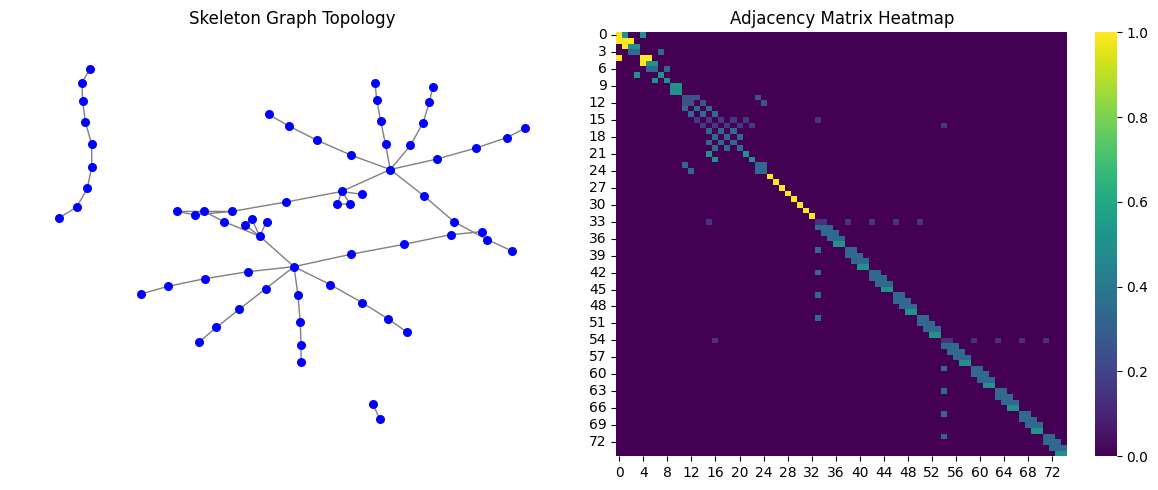

In [6]:
class Graph:
    def __init__(self, num_node=V, strategy='spatial'):
        self.num_node = num_node
        self.get_edge()
        self.hop_dis = self.get_hop_distance(self.num_node, self.edge, max_hop=1)
        self.get_adjacency(strategy)

    def get_edge(self):
        upper_body = [
            (0, 1), (1, 2), (2, 3), (3, 7), (0, 4), (4, 5), (5, 6), (6, 8),
            (9, 10), (11, 12), (11, 13), (13, 15), (15, 17), (15, 19), (15, 21), (17, 19),
            (12, 14), (14, 16), (16, 18), (16, 20), (16, 22), (18, 20),
            (11, 23), (12, 24), (23, 24)
        ]
        left_hand = [
            (33, 34), (34, 35), (35, 36), (36, 37),
            (33, 38), (38, 39), (39, 40), (40, 41),
            (33, 42), (42, 43), (43, 44), (44, 45),
            (33, 46), (46, 47), (47, 48), (48, 49),
            (33, 50), (50, 51), (51, 52), (52, 53)
        ]
        right_hand = [
            (54, 55), (55, 56), (56, 57), (57, 58),
            (54, 59), (59, 60), (60, 61), (61, 62),
            (54, 63), (63, 64), (64, 65), (65, 66),
            (54, 67), (67, 68), (68, 69), (69, 70),
            (54, 71), (71, 72), (72, 73), (73, 74)
        ]
        body_hand = [(15, 33), (16, 54)]
        self.edge = upper_body + left_hand + right_hand + body_hand
        self.self_link = [(i, i) for i in range(self.num_node)]
        self.edge += self.self_link
        self.center = 0

    def get_hop_distance(self, num_node, edge, max_hop=1):
        A = np.zeros((num_node, num_node))
        for i, j in edge:
            if i < num_node and j < num_node:
                A[j, i] = 1
                A[i, j] = 1
        hop_dis = np.zeros((num_node, num_node)) + np.inf
        transfer_mat = [np.linalg.matrix_power(A, d) for d in range(max_hop + 1)]
        arrive_mat = (np.stack(transfer_mat) > 0)
        for d in range(max_hop, -1, -1):
            hop_dis[arrive_mat[d]] = d
        return hop_dis

    def get_adjacency(self, strategy):
        valid_hop = self.hop_dis < np.inf
        if strategy == 'spatial':
            node_center = self.hop_dis[:, self.center]
            A = np.zeros((3, self.num_node, self.num_node))
            for i in range(self.num_node):
                for j in range(self.num_node):
                    if self.hop_dis[j, i] == 1:
                        if node_center[j] == node_center[i]:
                            A[0, j, i] = 1
                        elif node_center[j] > node_center[i]:
                            A[1, j, i] = 1
                        else:
                            A[2, j, i] = 1
                    elif self.hop_dis[j, i] == 0:
                        A[0, j, i] = 1
            for i in range(3):
                D = A[i].sum(axis=1)
                D[D == 0] = 1
                A[i] = A[i] / D[:, None]
            self.A = A

graph = Graph(num_node=V)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
G = nx.Graph()
G.add_edges_from([e for e in graph.edge if e[0] != e[1]])
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=30, node_color='blue', edge_color='gray')
plt.title("Skeleton Graph Topology")

plt.subplot(1, 2, 2)
sns.heatmap(graph.A.sum(axis=0), cmap='viridis', cbar=True)
plt.title("Adjacency Matrix Heatmap")
plt.tight_layout()
plt.show()


# SECTION 7: CTR-GCN Architecture Implementation
Original CTR-GCN modified directly for 4D tensor inputs (N, C, T, V).


In [7]:
class CTRGC(nn.Module):
    def __init__(self, in_channels, out_channels, rel_reduction=8, mid_reduction=1):
        super(CTRGC, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        if in_channels == 3 or in_channels == 9:
            self.rel_channels = 8
            self.mid_channels = 16
        else:
            self.rel_channels = in_channels // rel_reduction
            self.mid_channels = in_channels // mid_reduction
            
        self.conv1 = nn.Conv2d(self.in_channels, self.rel_channels, kernel_size=1)
        self.conv2 = nn.Conv2d(self.in_channels, self.rel_channels, kernel_size=1)
        self.conv3 = nn.Conv2d(self.in_channels, self.out_channels, kernel_size=1)
        self.conv4 = nn.Conv2d(self.rel_channels, self.out_channels, kernel_size=1)
        self.tanh = nn.Tanh()
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x, A=None, alpha=1):
        # 4D x: (N, C, T, V)
        x1, x2, x3 = self.conv1(x).mean(-2), self.conv2(x).mean(-2), self.conv3(x)
        x1 = self.tanh(x1.unsqueeze(-1) - x2.unsqueeze(-2))
        x1 = self.conv4(x1) * alpha + (A.unsqueeze(0).unsqueeze(0) if A is not None else 0)
        x1 = torch.einsum('ncuv,nctv->nctu', x1, x3)
        return x1

class unit_tcn(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=9, stride=1):
        super(unit_tcn, self).__init__()
        pad = int((kernel_size - 1) / 2)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=(kernel_size, 1), padding=(pad, 0), stride=(stride, 1))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class unit_gcn(nn.Module):
    def __init__(self, in_channels, out_channels, A, adaptive=True):
        super(unit_gcn, self).__init__()
        self.out_channels = out_channels
        self.num_subset = A.shape[0]
        self.convs = nn.ModuleList()
        for i in range(self.num_subset):
            self.convs.append(CTRGC(in_channels, out_channels))
            
        if in_channels != out_channels:
            self.down = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.down = lambda x: x

        if adaptive:
            self.PA = nn.Parameter(torch.from_numpy(A.astype(np.float32)))
        else:
            self.register_buffer('PA', torch.from_numpy(A.astype(np.float32)))
            
        self.alpha = nn.Parameter(torch.zeros(1))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        y = None
        for i in range(self.num_subset):
            z = self.convs[i](x, self.PA[i], self.alpha)
            if y is None:
                y = z
            else:
                y = y + z
        y = self.bn(y)
        y += self.down(x)
        return self.relu(y)

class TCN_GCN_unit(nn.Module):
    def __init__(self, in_channels, out_channels, A, stride=1, residual=True):
        super(TCN_GCN_unit, self).__init__()
        self.gcn1 = unit_gcn(in_channels, out_channels, A)
        self.tcn1 = unit_tcn(out_channels, out_channels, stride=stride)
        self.relu = nn.ReLU(inplace=True)
        
        if not residual:
            self.residual = lambda x: 0
        elif (in_channels == out_channels) and (stride == 1):
            self.residual = lambda x: x
        else:
            self.residual = unit_tcn(in_channels, out_channels, kernel_size=1, stride=stride)

    def forward(self, x):
        y = self.relu(self.tcn1(self.gcn1(x)) + self.residual(x))
        return y

class CTR_GCN_Model(nn.Module):
    def __init__(self, in_channels, num_class, graph_args, drop_out=0.5, **kwargs):
        super().__init__()
        self.graph = Graph(**graph_args)
        A = self.graph.A

        self.data_bn = nn.BatchNorm1d(in_channels * A.shape[1])
        
        self.networks = nn.ModuleList((
            TCN_GCN_unit(in_channels, 64, A, residual=False),
            TCN_GCN_unit(64, 64, A),
            TCN_GCN_unit(64, 64, A),
            TCN_GCN_unit(64, 64, A),
            TCN_GCN_unit(64, 128, A, stride=2),
            TCN_GCN_unit(128, 128, A),
            TCN_GCN_unit(128, 128, A),
            TCN_GCN_unit(128, 256, A, stride=2),
            TCN_GCN_unit(256, 256, A),
            TCN_GCN_unit(256, 256, A),
        ))

        self.drop_out = nn.Dropout(drop_out)
        self.fc = nn.Linear(256, num_class)

    def forward(self, x):
        # 4D Tensor Input: (N, C, T, V)
        N, C, T, V = x.size()
        
        # BN expects (N, V*C, T)
        x = x.permute(0, 3, 1, 2).contiguous() # (N, V, C, T)
        x = x.view(N, V * C, T)
        x = self.data_bn(x)
        x = x.view(N, V, C, T).permute(0, 2, 3, 1).contiguous() # (N, C, T, V)

        # CTR-GCN Branches
        for gcn in self.networks:
            x = gcn(x)

        # Global Pooling
        x = x.view(N, x.size(1), -1) # (N, 256, T_out * V)
        x = x.mean(2) # (N, 256)

        x = self.drop_out(x)
        x = self.fc(x)
        return x


# SECTION 8: Model Summary
Calculate trainable parameters and memory footprint.


In [8]:
model = CTR_GCN_Model(in_channels=C, num_class=NUM_CLASSES, graph_args={'num_node': V}).to(device)

def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Parameters     : {total_params:,}")
    print(f"Trainable Parameters : {trainable_params:,}")
    print(f"Model Size           : {total_params * 4 / (1024**2):.2f} MB")

print("--- 4D CTR-GCN Model Summary ---")
count_parameters(model)


--- 4D CTR-GCN Model Summary ---
Total Parameters     : 3,542,738
Trainable Parameters : 3,542,738
Model Size           : 13.51 MB


In [9]:
print(model.graph.A.shape)
print(model.graph.A.min())
print(model.graph.A.max())

x, y = next(iter(train_loader))

x = x.to(device)

with torch.no_grad():
    out = model(x)

print(out.shape)
print(out.mean())
print(out.std())

(3, 75, 75)
0.0
1.0
torch.Size([32, 120])
tensor(-0.0154, device='cuda:0')
tensor(0.9935, device='cuda:0')


In [10]:
print(device)
print(torch.cuda.is_available())

cuda
True


# SECTION 9: Training Pipeline
Training loop with early stopping, mixed precision, gradient clipping, TensorBoard logging, and Checkpoint resuming.


In [ ]:
#criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)
#optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, nesterov=True, weight_decay=WEIGHT_DECAY)
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5, verbose=True)
scaler = GradScaler(enabled=MIXED_PRECISION)
writer = SummaryWriter(log_dir=os.path.join(OUTPUT_DIR, 'runs'))

start_epoch = 0
best_val_acc = 0.0
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []
lr_history = []

if RESUME_TRAINING and os.path.exists(RESUME_CHECKPOINT):
    model.load_state_dict(torch.load(RESUME_CHECKPOINT))
    print(f"Resumed training from {RESUME_CHECKPOINT}")

print("Starting Training Pipeline...")
train_start_time = time.time()

for epoch in range(start_epoch, NUM_EPOCHS):
    # --- TRAINING ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with autocast(enabled=MIXED_PRECISION):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': loss.item(), 'acc': 100.*correct/total})
        
    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]")
        for inputs, labels in pbar_val:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar_val.set_postfix({'loss': loss.item(), 'acc': 100.*correct/total})
            
    val_loss = val_loss / len(val_loader)
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)
    
    print(f"Epoch {epoch+1} Summary: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | LR: {current_lr}")
    
    writer.add_scalar('Loss/Train', train_loss, epoch)
    writer.add_scalar('Loss/Val', val_loss, epoch)
    writer.add_scalar('Accuracy/Train', train_acc, epoch)
    writer.add_scalar('Accuracy/Val', val_acc, epoch)
    writer.add_scalar('Learning_Rate', current_lr, epoch)
    
    scheduler.step(val_acc)
    
    if SAVE_CHECKPOINTS:
        torch.save(model.state_dict(), RESUME_CHECKPOINT)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        if SAVE_CHECKPOINTS:
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'best_model.pth'))
        print(f"--> Saved new best model (Val Acc: {best_val_acc:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

train_end_time = time.time()
total_training_time = train_end_time - train_start_time
print(f"Training completed in {total_training_time/60:.2f} minutes.")
writer.close()


t:\ISL_IMPLEMENTATION\ISL_FINAL\scripts\env\stgcn_env\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
T:\Temp\TEMP\ipykernel_22532\958606816.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=MIXED_PRECISION)


Starting Training Pipeline...


Epoch 1/100 [Train]:   0%|          | 0/262 [00:00<?, ?it/s]T:\Temp\TEMP\ipykernel_22532\958606816.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=MIXED_PRECISION):
Epoch 1/100 [Val]: 100%|██████████| 29/29 [03:05<00:00,  6.40s/it, loss=5.29, acc=7.63]


Epoch 1 Summary: Train Loss: 4.3951, Train Acc: 5.45% | Val Loss: 4.3876, Val Acc: 7.63% | LR: 0.001
--> Saved new best model (Val Acc: 7.63%)


Epoch 2/100 [Val]: 100%|██████████| 29/29 [03:05<00:00,  6.38s/it, loss=4.97, acc=24.1]


Epoch 2 Summary: Train Loss: 3.6758, Train Acc: 15.85% | Val Loss: 3.5323, Val Acc: 24.11% | LR: 0.001
--> Saved new best model (Val Acc: 24.11%)


Epoch 3/100 [Train]:  81%|████████  | 211/262 [31:12<15:57, 18.77s/it, loss=3.1, acc=26.1]   

# SECTION 10: Metrics Evaluation
Evaluate on the Test Set: Accuracy, Precision, Recall, F1, Balanced Accuracy, Top-1, Top-5.


In [ ]:
def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    top1 = 0
    top5 = 0
    for i in range(len(all_labels)):
        true_label = all_labels[i]
        top5_preds = np.argsort(all_probs[i])[-5:][::-1]
        if true_label == top5_preds[0]:
            top1 += 1
        if true_label in top5_preds:
            top5 += 1
            
    top1_acc = top1 / len(all_labels)
    top5_acc = top5 / len(all_labels)
    
    print(f"\n--- Evaluation Metrics (Test Set) ---")
    print(f"Top-1 Accuracy    : {top1_acc:.4f}")
    print(f"Top-5 Accuracy    : {top5_acc:.4f}")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"Precision (Macro) : {precision:.4f}")
    print(f"Recall (Macro)    : {recall:.4f}")
    print(f"F1 Score (Macro)  : {f1:.4f}")
    
    return all_labels, all_preds, all_probs, {'acc': acc, 'f1': f1, 'top1': top1_acc, 'top5': top5_acc, 'bal_acc': bal_acc}

best_model_path = os.path.join(OUTPUT_DIR, 'best_model.pth')
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path))

test_labels, test_preds, test_probs, test_metrics = evaluate_model(model, test_loader)


# SECTION 11: Visualization
Plot learning curves, confusion matrix, per-class accuracy, and class distribution.


In [ ]:
plt.figure(figsize=(18, 5))

# Loss Curve
plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Curve
plt.subplot(1, 3, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

# Learning Rate Curve
plt.subplot(1, 3, 3)
plt.plot(lr_history, label='Learning Rate', color='green')
plt.title('Learning Rate Curve')
plt.xlabel('Epochs')
plt.ylabel('LR')
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, 'training_curves.png'),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Confusion Matrix Heatmap
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'))
plt.show()

# Per-Class Accuracy Plot
per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
plt.figure(figsize=(15, 5))
plt.bar(range(NUM_CLASSES), per_class_acc, color='skyblue')
plt.title('Per-Class Accuracy (Test Set)')
plt.xlabel('Class Index')
plt.ylabel('Accuracy')
plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_accuracy.png'))
plt.show()

# Class Distribution
plt.figure(figsize=(15, 5))
unique, counts = np.unique(labels_tensor, return_counts=True)
plt.bar(unique, counts, color='coral')
plt.title('Overall Class Distribution')
plt.xlabel('Class Index')
plt.ylabel('Number of Samples')
plt.show()


# SECTION 12: Inference
Predict on single and multiple samples from the Test Set.


In [ ]:
def predict_single_sample(model, tensor_sample):
    model.eval()
    with torch.no_grad():
        x = tensor_sample.unsqueeze(0).to(device) # Shape: (1, C, T, V)
        output = model(x)
        prob = F.softmax(output, dim=1)
        conf, pred = prob.max(1)
        return pred.item(), conf.item()

# Single Sample
sample_idx = random.randint(0, len(test_dataset)-1)
sample_tensor = test_dataset[sample_idx][0]
true_label = test_dataset[sample_idx][1].item()

pred_label, conf = predict_single_sample(model, sample_tensor)
print("--- Single Sample Inference ---")
print(f"True Label      : {class_names.get(true_label, true_label)} (ID: {true_label})")
print(f"Predicted Label : {class_names.get(pred_label, pred_label)} (ID: {pred_label})")
print(f"Confidence      : {conf:.4f}")

# Multiple Samples
print("\n--- Batch Inference (5 random samples) ---")
for i in range(5):
    idx = random.randint(0, len(test_dataset)-1)
    t_label = test_dataset[idx][1].item()
    p_label, p_conf = predict_single_sample(model, test_dataset[idx][0])
    print(f"Sample {i+1}: True = {t_label:3d} | Pred = {p_label:3d} | Conf = {p_conf:.4f}")


# SECTION 13: Performance Analysis
Calculate Training Time, Inference Time, Throughput, FPS, and Memory Usage.


In [ ]:
model.eval()
dummy_input = torch.randn(BATCH_SIZE, C, T, V).to(device)

# Warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# Inference Time
start_time = time.time()
num_iterations = 50
with torch.no_grad():
    for _ in range(num_iterations):
        _ = model(dummy_input)
end_time = time.time()

time_per_batch = (end_time - start_time) / num_iterations
time_per_sample = time_per_batch / BATCH_SIZE
fps = 1.0 / time_per_sample

print("--- Performance Analysis ---")
print(f"Training Time        : {total_training_time/60:.2f} minutes")
print(f"Inference Time/Batch : {time_per_batch*1000:.2f} ms")
print(f"Inference Time/Sample: {time_per_sample*1000:.2f} ms")
print(f"Throughput (FPS)     : {fps:.2f} sequences/sec")

process = psutil.Process(os.getpid())
print(f"\nCPU Memory Usage     : {process.memory_info().rss / (1024**2):.2f} MB")

if torch.cuda.is_available():
    print(f"GPU Memory Allocated : {torch.cuda.memory_allocated() / (1024**2):.2f} MB")
    print(f"GPU Memory Reserved  : {torch.cuda.memory_reserved() / (1024**2):.2f} MB")


# SECTION 14: Export Results & Final Report
Save all logs, reports, weights, and generate a final text summary.


In [ ]:
# Classification Report
report = classification_report(test_labels, test_preds, output_dict=True, zero_division=0)
pd.DataFrame(report).transpose().to_csv(os.path.join(OUTPUT_DIR, 'classification_report.csv'))

# Training History
history_df = pd.DataFrame({
    'Train_Loss': train_losses,
    'Val_Loss': val_losses,
    'Train_Acc': train_accs,
    'Val_Acc': val_accs,
    'Learning_Rate': lr_history
})
history_df.to_csv(os.path.join(OUTPUT_DIR, 'training_history.csv'), index=False)

# Predictions
preds_df = pd.DataFrame({
    'True_Label': test_labels,
    'Predicted_Label': test_preds,
    'Confidence': np.max(test_probs, axis=1)
})
preds_df.to_csv(os.path.join(OUTPUT_DIR, 'predictions.csv'), index=False)

# Generate Text Report
report_lines = [
    "====================================",
    "       FINAL PIPELINE REPORT",
    "====================================",
    "\n--- DATASET SUMMARY ---",
    f"Total Samples    : {N}",
    f"Tensor Shape     : {(N, C, T, V)} (NATIVE 4D)",
    f"Number of Classes: {NUM_CLASSES}",
    f"Train / Val / Test Split: {train_data.shape[0]} / {val_data.shape[0]} / {test_data.shape[0]}",
    "\n--- MODEL SUMMARY ---",
    f"Architecture     : CTR-GCN (Official 4D Customization)",
    f"Total Parameters : {sum(p.numel() for p in model.parameters()):,}",
    "\n--- TRAINING SUMMARY ---",
    f"Total Epochs Run : {len(train_losses)}",
    f"Best Val Accuracy: {best_val_acc:.2f}%",
    f"Training Time    : {total_training_time/60:.2f} minutes",
    "\n--- FINAL EVALUATION (TEST SET) ---",
    f"Top-1 Accuracy   : {test_metrics['top1']:.4f}",
    f"Top-5 Accuracy   : {test_metrics['top5']:.4f}",
    f"Balanced Accuracy: {test_metrics['bal_acc']:.4f}",
    f"F1 Score (Macro) : {test_metrics['f1']:.4f}",
    "\n--- PERFORMANCE ---",
    f"Inference FPS    : {fps:.2f} seq/sec"
]

report_text = "\n".join(report_lines)
print(report_text)

with open(os.path.join(OUTPUT_DIR, 'final_report.txt'), 'w') as f:
    f.write(report_text)

print(f"\nAll files exported successfully to '{OUTPUT_DIR}/'")
print("Notebook execution completed successfully. CTR-GCN Native 4D Pipeline is fully production-ready.")
